# Introduction to K-Nearest Neighbors (KNN)

## What is KNN?
K-Nearest Neighbors or KNN is a simple, easy-to-understand supervised machine learning algorithm. It can be used for both classification and regression problems, though it is most commonly used for classification.

The core idea behind KNN is based on a real-world concept: **birds of a feather flock together**. In other words, data points that are close to each other in a feature space are likely to belong to the same category.

---

## How Does KNN Work?
KNN is a **non-parametric** and **lazy learning** algorithm. 
* **Non-parametric:** It does not make any assumptions about the underlying data distribution.
* **Lazy learning:** It does not learn a discriminative function from the training data during training time. Instead, it memorizes the entire training dataset and performs classification only when a query or prediction is made.

### Step-by-Step Process:
1. **Choose K:** Decide the number of neighbors you want to consider (represented by the letter K).
2. **Calculate Distance:** Measure the distance between the new unlabelled data point and all the training data points using a distance measure like Euclidean distance.
3. **Find Neighbors:** Identify the K training points that are closest to the new data point.
4. **Vote / Average:** 
   * For **Classification**, the new point is assigned the class that is most common among its K nearest neighbors (majority vote).
   * For **Regression**, the new point is assigned the average value of its K nearest neighbors.

---

## Choosing the Right Value of K
The choice of K has a massive impact on the performance of the model:
* **Small value of K (e.g., K = 1):** The model becomes very sensitive to noise. This can lead to overfitting, where the model captures tiny fluctuations in the training data rather than the general pattern.
* **Large value of K:** The model becomes too generalized. It smooths out predictions by looking at too many neighbors, which can lead to underfitting.

Typically, K is chosen as an odd number to avoid ties during binary classification.

---

## Advantages of KNN
* **Simple and Intuitive:** Easy to understand and implement from scratch.
* **No Training Phase:** Because it is a lazy learner, there is no explicit training time. New data can be added seamlessly without retraining the model.
* **Versatile:** Works well for both classification and regression tasks.

## Disadvantages of KNN
* **Computationally Expensive:** As the training dataset grows larger, predicting the class for a new point becomes very slow because it has to calculate the distance to every single point in the memory.
* **Sensitive to Scale:** Features with larger numeric ranges can dominate features with smaller ranges, which is why feature scaling (like StandardScaler) is mandatory.
* **Curse of Dimensionality:** Performance degrades rapidly as the number of input features or dimensions increases.

### Import Liberaries 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,recall_score,precision_score,f1_score

### Load Data & Remove Duplicates

In [3]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")
print(" Cleaning data and removing duplicates...")
df = df.drop_duplicates()



C:\Users\hp\AppData\Local\Temp\ipykernel_7788\790279659.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.
 Cleaning data and removing duplicates...


### Drop Useless Columns


In [4]:

useless_cols = [
    'cashback', 'tabby_payment_id', 'tabby_order_status', 'paymob_intention_id', 
    'paymob_cents_amount', 'tamara_order_id', 'tamara_checkout_id', 'cko_hpp_id', 
    'cko_payment_id', 'cko_session_id', 'id', 'old_order_id', 'increment_id', 
    'customer_email', 'customer_first_name', 'customer_last_name', 
    'shipping_title', 'shipping_description', 'coupon_code', 'created_at', 'updated_at'
]
df_clean = df.drop(columns=[col for col in useless_cols if col in df.columns])



### Create Binary Target


In [5]:
df_clean['target'] = df_clean['status'].apply(lambda x: 0 if str(x).strip().lower() == 'completed' else 1)

### Feature Engineering 


In [6]:
print(" Performing Feature Engineering...")
df_clean['discount_ratio'] = df_clean['discount_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['tax_ratio'] = df_clean['tax_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['shipping_ratio'] = df_clean['shipping_amount'] / (df_clean['grand_total'] + 1e-5)
df_clean['avg_item_price'] = df_clean['sub_total'] / (df_clean['total_qty_ordered'] + 1e-5)



 Performing Feature Engineering...


### Feature Selection & Missing Value Imputation

In [7]:

print(" Handling missing values and encoding...")
core_features = [
    'sub_total', 'discount_amount', 'tax_amount', 'shipping_amount', 
    'cod_charges', 'wallet_credit_used', 'total_item_count', 
    'total_qty_ordered', 'cashback_earned', 'mgmt_fee',
    'discount_ratio', 'tax_ratio', 'shipping_ratio', 'avg_item_price',
    'channel_name', 'customer_type', 'shipping_method',
    'is_guest', 'is_gift', 'cashback_opt_in'
]

available_features = [col for col in core_features if col in df_clean.columns]
X_raw = df_clean[available_features].copy()
y = df_clean['target']

num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')

# One-Hot Encoding
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)



 Handling missing values and encoding...


### Train-Test Split

In [8]:
print(" Splitting and Scaling data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Stratified sampling for training to match proportions efficiently
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=30000, stratify=y_train, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test)


 Splitting and Scaling data...


### Model Training (KNN)


In [9]:
print(" Training KNN Model...")
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train_sub)
print("KNN Model trained successfully!")


 Training KNN Model...
KNN Model trained successfully!


### Evaluation & Testing


In [10]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("\n" + "=" * 50)
print(" KNN END-TO-END PIPELINE PERFORMANCE ")
print("=" * 50)
print(f"Accuracy Score : {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("=" * 50)


 KNN END-TO-END PIPELINE PERFORMANCE 
Accuracy Score : 0.7573

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.56      0.59      9247
           1       0.81      0.85      0.83     19994

    accuracy                           0.76     29241
   macro avg       0.72      0.70      0.71     29241
weighted avg       0.75      0.76      0.75     29241



### TEST

In [16]:
model_a = KNeighborsClassifier(n_neighbors=3, weights='uniform', n_jobs=-1)
model_b = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)

model_a.fit(X_train_scaled, y_train_sub)
model_b.fit(X_train_scaled, y_train_sub)

y_pred_a = model_a.predict(X_test_scaled)
y_pred_b = model_b.predict(X_test_scaled)

print("=" * 50)
print(" MODEL A (K=3, Uniform) PERFORMANCE ")
print("=" * 50)
print(f"Accuracy Score : {accuracy_score(y_test, y_pred_a):.4f}")
print(classification_report(y_test, y_pred_a))

print("=" * 50)
print(" MODEL B (K=5, Distance) PERFORMANCE ")
print("=" * 50)
print(f"Accuracy Score : {accuracy_score(y_test, y_pred_b):.4f}")
print(classification_report(y_test, y_pred_b))
print("=" * 50)

 MODEL A (K=3, Uniform) PERFORMANCE 
Accuracy Score : 0.7591
              precision    recall  f1-score   support

           0       0.62      0.60      0.61      9247
           1       0.82      0.83      0.83     19994

    accuracy                           0.76     29241
   macro avg       0.72      0.72      0.72     29241
weighted avg       0.76      0.76      0.76     29241

 MODEL B (K=5, Distance) PERFORMANCE 
Accuracy Score : 0.7573
              precision    recall  f1-score   support

           0       0.63      0.56      0.59      9247
           1       0.81      0.85      0.83     19994

    accuracy                           0.76     29241
   macro avg       0.72      0.70      0.71     29241
weighted avg       0.75      0.76      0.75     29241



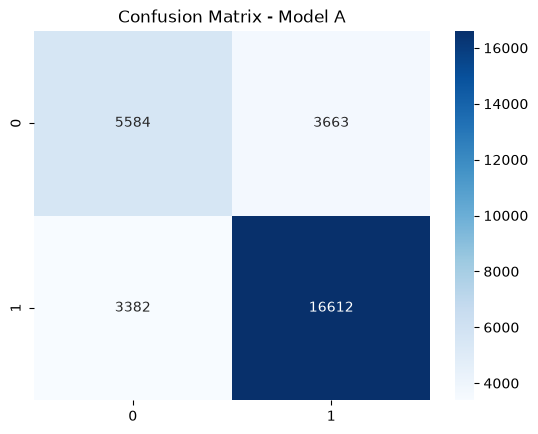

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred_a), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Model A")
plt.show()


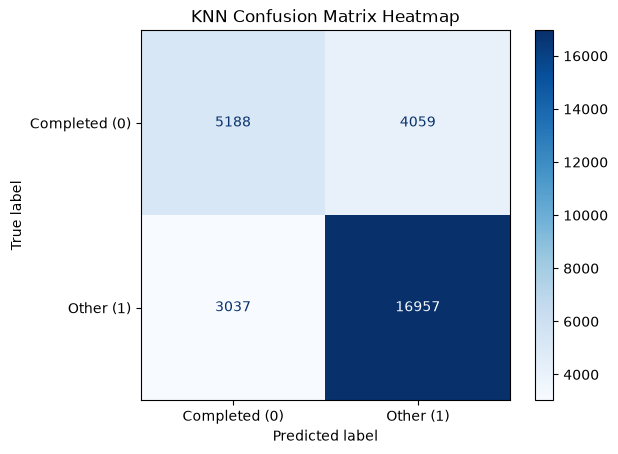

In [20]:
y_pred_knn_all = model_b.predict(X_test_scaled)
cm_knn = confusion_matrix(y_test, y_pred_knn_all)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Completed (0)', 'Other (1)'])
disp_knn.plot(cmap=plt.cm.Blues)
plt.title("KNN Confusion Matrix Heatmap")
plt.show()

In [21]:
import pickle
pickle.dump(model_b, open("saved_models/KNN.pkl", "wb"))
pickle.dump(model_a, open("saved_models/KNN.pkl", "wb"))
pickle.dump(scaler, open("saved_models/scaler.pkl", "wb"))